# Prediction quality across contractive input geometry, penalty metric and weight

This notebook measures how the molecule classification head's quality changes as the
contractive penalty varies over two input geometries, four penalty metrics and five
weights, against an unregularized baseline trained on the same split. It asks whether any
penalty configuration improves multi-label prediction, and separates changes in ranking
quality from changes that are purely an artifact of the decision threshold.

The penalty acts on the encoder, not on the head, so any effect here is mediated by the
representation. `part_2` measures that representation directly and `part_3` combines the
two into a decision.

## Introduction

Two sweep campaigns and one baseline are pooled. The Euclidean sweep varies the penalty
metric over Frobenius, spectral and a legacy Frobenius hinge; the Fisher-Rao sweep varies
it over Frobenius, spectral and a combined spectral-plus-hinge penalty on the TIC
simplex. Both use the canonicalized latent $u$ as the penalized space.

A central distinction runs through the whole notebook. `average_precision` and `roc_auc`
depend only on the *ranking* the head induces and are invariant to any strictly
increasing rescaling of its scores. Every other metric reported here is evaluated at a
fixed probability threshold and therefore moves when the score *scale* moves, even if the
ranking is untouched. A contractive penalty shrinks the encoder's Jacobian, which shrinks
latent variation, which shrinks logit spread through a fixed head. That mechanism changes
threshold metrics without changing ranking metrics, and reading a threshold metric alone
would attribute a calibration shift to a loss of information. Both families are therefore
recorded and compared explicitly.

### Assumptions

- **The compared models share their data.** All campaigns use the same binning, subset
  fraction, split strategy and split seed, verified in `part_0_2`. The head architecture,
  its loss and its class-balancing scheme are identical across cells; only the encoder's
  regularization differs.
- **Both splits are evaluated in full.** The dataset decodes each spectrum from the raw
  reader on access, so each split is decoded once and the resulting tensors are shared by
  every model rather than re-decoded per model. Every metric here is evaluated as batched
  tensor operations over the class axis, which is what makes the complete split tractable
  across 140 models; the decoded indices are persisted alongside the results.
- **Fair scope conditions on label availability.** A class with no available positive in
  the training sample cannot have been learned, and one with none in the evaluation
  sample has an undefined average precision. Metrics over all classes therefore mix model
  quality with label availability; every result is reported in both scopes so the two can
  be told apart.
- **Unavailable labels are treated as the head's training loss treats them.** The head was
  trained with `unknown_label_policy: assume_negative`. Evaluation applies the recorded
  availability mask instead, so a class absent from the annotation is excluded rather than
  scored as a true negative. This makes the reported values stricter than the training
  objective's own view.
- **Five repetitions per cell bound the seed noise, not the population.** Intervals below
  describe variation across run seeds for this one dataset and split. They do not support
  claims about other tissue samples.

### Notation

The model maps a binned spectrum $x \in \mathbb{R}^{M}$ to a latent code and a head score:

$$
x \xrightarrow{\ \mathrm{Enc}\ } z \in \mathbb{R}^{D}
\xrightarrow{\ h\ } s \in \mathbb{R}^{C},
\qquad
\hat y = \sigma(s),
$$

with $M$ m/z bins, latent dimension $D$, $C$ molecule classes and $\sigma$ the elementwise
logistic function. A grid cell is $c=(\text{geometry},\text{penalty metric},\lambda)$,
trained in repetitions $r = 0,\dots,4$. For class $k$, $y_{ik}\in\{0,1\}$ is the target of
sample $i$ and $m_{ik}\in\{0,1\}$ its availability mask. $\mathcal{K}$ denotes the
evaluated class scope.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import spearmanr

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import contractive_precompute as precompute
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import penalty_sweep as sweep
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import sweep_evaluation as evaluation
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

logger = get_custom_logger("prediction_sweep")

2026-09-09 17:23:33,375 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-09 17:23:33,379 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


## Producing the tables this notebook reads

### Methodology

#### Implementation

No model is loaded and no inference runs in this notebook. Evaluating the pooled sweep
means loading every completed run and passing both splits through it, which takes minutes
on a GPU and would tie the result to a kernel that can die halfway. That work lives in
`contractive_precompute.prediction_sweep`, is configured by `analysis_settings.yaml` next
to this notebook, and writes its tables to this notebook's results directory.

Run it once, detached, with the command printed below; it refuses to start on the
processor unless explicitly allowed, since a CPU torch build turns minutes into hours
without saying so. The command is generated by the runner itself rather than written out
here, so the instruction cannot drift from the entry point it describes.

Everything after this section reads those tables. Re-running the notebook re-draws the
figures in seconds and recomputes only the cheap derived summaries.

### Remarks

### Notes

## Configuration and evaluation sample

In [2]:
SETTINGS_PATH = Path(
    "assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/analysis_settings.yaml"
)
ANALYSIS = "prediction_sweep"

settings = precompute.read_settings(SETTINGS_PATH)
ARTIFACT_DIR = precompute.analysis_settings(settings, ANALYSIS)["output_directory"]

# Seeds and sample settings come from the settings file, so the notebook and the
# precompute cannot drift apart on them.
SAMPLE_SEED = int(settings["sample_seed"])

theme = resolve_theme(None)
theme.apply()

# --- embedded figure resolution --------------------------------------------
# Inline figures are stored inside the notebook as PNG. Rendering them at 100
# dpi instead of the theme's 140 roughly halves the stored size, leaving figure
# geometry and font proportions untouched, so the notebook stays openable in
# viewers that fall back to the text output on very large images.
FIGURE_RASTER_DPI = 100
plt.rcParams["savefig.dpi"] = FIGURE_RASTER_DPI
# ---------------------------------------------------------------------------

print("Run the precompute once, in the background:")
print(f"  {precompute.run_command(settings, ANALYSIS)}")
print("\nOr in the foreground, to watch it:")
print(f"  {precompute.run_command(settings, ANALYSIS, background=False)}")

Run the precompute once, in the background:
  nohup python -m msi_autoencoder_wrapper.analysis.autoencoder.experiments.contractive_precompute --settings assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/analysis_settings.yaml --analysis prediction_sweep > assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/part_1_prediction_metric_weight_sweep_results/prediction_sweep.log 2>&1 &

Or in the foreground, to watch it:
  python -m msi_autoencoder_wrapper.analysis.autoencoder.experiments.contractive_precompute --settings assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/analysis_settings.yaml --analysis prediction_sweep


In [3]:
# Tables produced by the command above; `load_table` reports the command again if one
# is missing, so a fresh checkout fails with an instruction rather than a stack trace.
grid_frame = precompute.load_table(settings, ANALYSIS, "grid")
prediction_frame = precompute.load_table(settings, ANALYSIS, "prediction_metrics")
per_class_frame = precompute.load_table(settings, ANALYSIS, "per_class_metrics")
spread_frame = precompute.load_table(settings, ANALYSIS, "calibration_diagnostic").set_index("cell_label")
sample_indices = precompute.load_table(settings, ANALYSIS, "sample_indices")

provenance = precompute.load_metadata(settings, ANALYSIS)
positive_rate = provenance["empirical_positive_rate_fair_scope"]

print(f"{len(grid_frame)} run(s) across {grid_frame['cell_label'].nunique()} grid cell(s)")
print(f"{len(prediction_frame)} prediction row(s), {prediction_frame['metric'].nunique()} metric(s)")
print(f"{len(per_class_frame)} per-class row(s) over {per_class_frame['class_index'].nunique()} class(es)")
print(f"splits: {provenance['splits']}, fair scope {provenance['classes_fair_scope']}/{provenance['classes_total']} classes")
print(f"precomputed at commit {provenance['git_commit']} on {provenance['device']}")

140 run(s) across 28 grid cell(s)
5600 prediction row(s), 10 metric(s)
14224 per-class row(s) over 508 class(es)
splits: {'train': {'sampled': 33650, 'total': 33650}, 'test': {'sampled': 4205, 'total': 4205}}, fair scope 508/508 classes
precomputed at commit d52fbf0d49fd31716ead9d97121b2ab7a23147c9 on cuda


## What each reported metric measures

### Methodology

#### Theoretical

Every metric below is computed over the evaluated class scope $\mathcal{K}$ and only over
entries whose availability mask is set. Write $\mathrm{TP}_k,\mathrm{FP}_k,\mathrm{FN}_k$
for the class-$k$ counts at threshold $\tau=0.5$.

**Ranking metrics, invariant to a monotone rescaling of scores.**

- *Average precision*, reported as `average_precision`, is the macro mean over classes of
  the area under each class's precision-recall curve,
  $\mathrm{AP}_k=\sum_n (R_{k,n}-R_{k,n-1})P_{k,n}$, summed over all thresholds $n$ that
  the scores induce. It uses no fixed threshold. Classes with no available positive are
  undefined and excluded from the mean. It is the primary metric here because the task is
  strongly imbalanced and the operating threshold is not fixed by any downstream use.
- *ROC AUC*, `roc_auc`, is the macro mean of the area under each class's receiver
  operating characteristic, equal to the probability that a random available positive
  outranks a random available negative. Under heavy class imbalance it is dominated by
  true negatives and moves far less than average precision, so a gap between the two is
  informative rather than contradictory.

**Threshold metrics, evaluated at $\tau=0.5$ and sensitive to score scale.**

- *Macro precision, recall and F1*, `macro_precision`, `macro_recall`, `macro_f1`, average
  the per-class quantities $P_k=\mathrm{TP}_k/(\mathrm{TP}_k+\mathrm{FP}_k)$,
  $R_k=\mathrm{TP}_k/(\mathrm{TP}_k+\mathrm{FN}_k)$ and their harmonic mean over classes,
  weighting every class equally regardless of prevalence. With several hundred mostly rare
  classes these are dominated by the rare ones.
- *Micro precision, recall and F1*, `micro_precision`, `micro_recall`, `micro_f1`, pool the
  counts over all classes before forming the ratio, $P=\sum_k \mathrm{TP}_k/\sum_k
  (\mathrm{TP}_k+\mathrm{FP}_k)$, so they are dominated by frequent classes. A macro and a
  micro value that move in opposite directions localize an effect to the rare or the
  frequent classes respectively.
- *Hamming loss*, `hamming_loss`, is the fraction of available (sample, class) entries
  whose thresholded prediction differs from the target. It is reported together with
  `hamming_loss_baseline_positive_rate`, the fraction of available entries that are
  positive, which is exactly the Hamming loss of a predict-nothing model. A Hamming loss
  at or above that rate means the head is not beating the trivial all-negative predictor
  at this threshold.

**Why the split matters here.** A penalty that shrinks the latent shrinks the logit
spread, so probabilities contract toward the prior and, at a fixed $\tau=0.5$, positives
stop crossing it. That reduces recall and F1 while leaving average precision unchanged,
because the ranking survives. The correlation section below tests directly whether the
observed movements have this signature.

#### Implementation

All values come from `evaluate_head`, the same implementation the head analyses elsewhere
in this project use; nothing is reimplemented here. Per-class values come from
`per_class_metrics`. Probabilities are obtained from logits with
`probabilities_from_logits` under the `multi_label` convention, i.e. an elementwise
logistic, not a softmax. The availability mask is passed through unchanged at one flag per
(sample, class) pair.

### Remarks

### Notes

## Prediction metrics across the grid

### Methodology

#### Theoretical

Each cell is evaluated in five repetitions on both the training and the evaluation split.
Reporting the training split is not redundant: the gap between the two is the only direct
evidence of whether a penalty acts as a regularizer, which is what a contractive term is
supposed to do. A penalty that reduces the gap while holding evaluation quality is
succeeding; one that reduces both is merely shrinking the model.

#### Implementation

`evaluate_campaign_models` loads each of the completed runs once and evaluates both splits
from the same loaded model, in both class scopes. Output is long form, one row per
(model, split, scope, metric), so no repetition is collapsed at computation time. Per-class
records are collected for the evaluation split within the fair scope only, since per-class
average precision on the training split answers no question asked here and dominates the
runtime.

#### Figure descriptions

The table that follows reports, per cell and scope, the mean across repetitions of every
metric on the evaluation split. It exists to give the numeric level; the distributions are
what the figures below show.

### Remarks

### Notes

In [4]:
# Grid cell ordering and colours, derived from the loaded grid.
# (The evaluation that produced `prediction_frame` runs in the precompute.)
print(f"{len(prediction_frame)} prediction row(s) loaded for "
      f"{prediction_frame['cell_label'].nunique()} cell(s)")

5600 prediction row(s) loaded for 28 cell(s)


In [5]:
METRIC_ORDER = [
    "average_precision", "roc_auc",
    "macro_f1", "macro_precision", "macro_recall",
    "micro_f1", "micro_precision", "micro_recall",
    "hamming_loss", "hamming_loss_baseline_positive_rate",
]
CELL_ORDER = (
    grid_frame.drop_duplicates("cell_label")
    .sort_values(["input_geometry", "penalty_metric", "weight"], na_position="first")
    ["cell_label"].tolist()
)
FAMILY_OF = grid_frame.drop_duplicates("cell_label").set_index("cell_label")[["input_geometry", "penalty_metric"]]
FAMILIES = sorted({tuple(FAMILY_OF.loc[cell]) for cell in CELL_ORDER})
FAMILY_COLOR = {family: theme.color_for_model("/".join(family), index) for index, family in enumerate(FAMILIES)}
CELL_COLOR = {cell: FAMILY_COLOR[tuple(FAMILY_OF.loc[cell])] for cell in CELL_ORDER}

test_frame = prediction_frame.query("split == 'test'")
display(
    test_frame.query("scope == @evaluation.FAIR_SCOPE")
    .pivot_table(index="cell_label", columns="metric", values="value", aggfunc="mean")
    .reindex(CELL_ORDER)[METRIC_ORDER].round(4)
)

metric,average_precision,roc_auc,macro_f1,macro_precision,macro_recall,micro_f1,micro_precision,micro_recall,hamming_loss,hamming_loss_baseline_positive_rate
cell_label,,,,,,,,,,
euclidean / frobenius / w=1e-05,0.6541,0.9874,0.5853,0.4961,0.8205,0.7931,0.6645,0.9836,0.0253,0.0494
euclidean / frobenius / w=1e-04,0.6221,0.9839,0.5746,0.4872,0.8050,0.7858,0.6553,0.9813,0.0264,0.0494
euclidean / frobenius / w=1e-03,0.5622,0.9771,0.5486,0.4591,0.7809,0.7674,0.6333,0.9738,0.0291,0.0494
euclidean / frobenius / w=1e-02,0.4750,0.9665,0.4731,0.3904,0.6833,0.7209,0.5808,0.9505,0.0364,0.0494
euclidean / hinged / w=1e-05 / tau=400,0.6678,0.9889,0.5899,0.4996,0.8248,0.7973,0.6701,0.9842,0.0247,0.0494
euclidean / hinged / w=1e-04 / tau=400,0.6617,0.9880,0.5861,0.4968,0.8259,0.7941,0.6655,0.9842,0.0252,0.0494
euclidean / hinged / w=1e-03 / tau=400,0.6648,0.9886,0.5866,0.4962,0.8285,0.7953,0.6670,0.9846,0.0250,0.0494
euclidean / hinged / w=1e-02 / tau=400,0.6655,0.9886,0.5882,0.4996,0.8250,0.7961,0.6683,0.9844,0.0249,0.0494
baseline (no contractive),0.6746,0.9890,0.5921,0.5018,0.8286,0.7980,0.6708,0.9847,0.0246,0.0494


## Distribution of every metric across repetitions

### Methodology

#### Theoretical

A mean over five repetitions cannot distinguish a consistent shift from one divergent
seed, and those two have opposite consequences for a decision. Every metric is therefore
shown as its full distribution over repetitions, with all five observations drawn.

#### Implementation

One panel per metric, one violin per grid cell, with all five repetition values overlaid
as points. The distribution uses every observation, not a subsample. The baseline appears
as its own cell so the comparison is visual rather than arithmetic.

#### Figure descriptions

A grid of panels, one per metric named in the panel title. Within a panel the x-axis lists
grid cells ordered by input geometry, then penalty metric, then weight; the y-axis is the
metric value on the evaluation split within the fair scope. Each violin is the
distribution over the five repetitions of that cell and each point is one repetition.
Color encodes the penalty family, so the Euclidean and Fisher-Rao arms of the same penalty
metric are distinguishable. The dashed horizontal line is the baseline's mean. For
`hamming_loss` lower is better and for every other metric higher is better, except
`hamming_loss_baseline_positive_rate`, which is a property of the labels and is expected
to be constant across cells; its variation would indicate an evaluation-set inconsistency
rather than a model difference.

### Remarks

### Notes

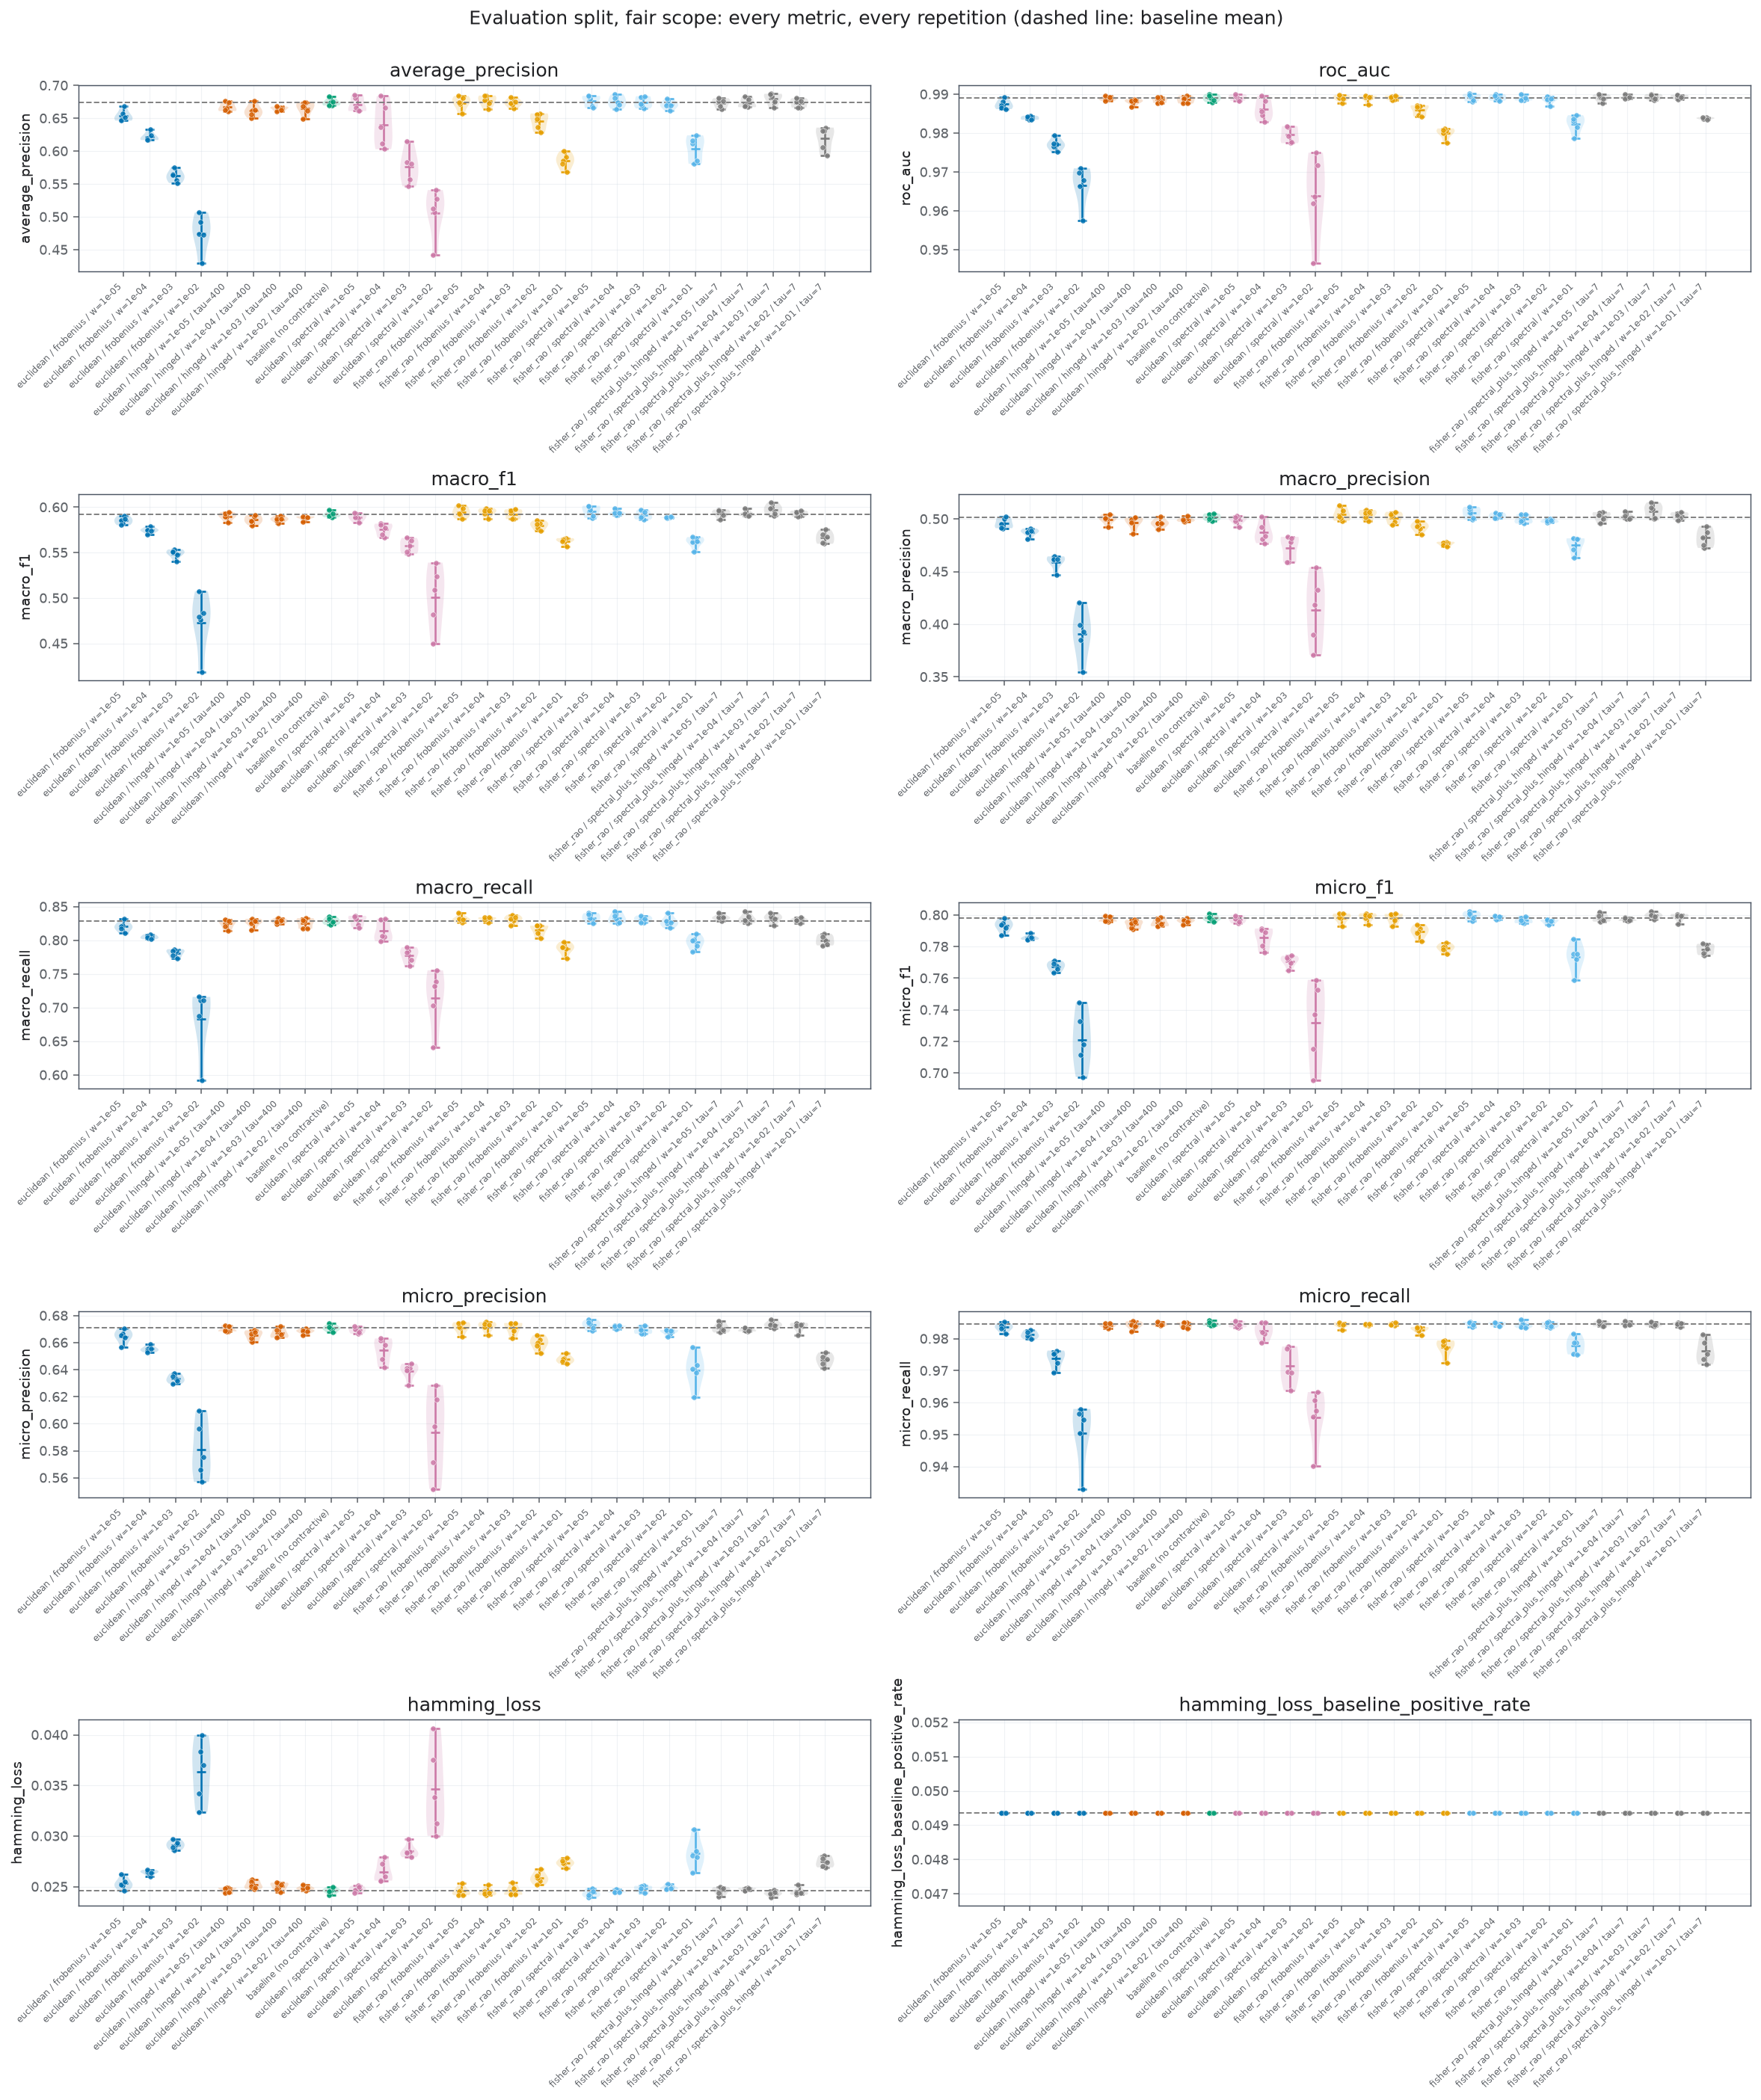

In [6]:
def metric_samples(frame, metric, scope, split="test"):
    selected = frame.query("metric == @metric and scope == @scope and split == @split")
    return {cell: group["value"].to_numpy() for cell, group in selected.groupby("cell_label")}


def plot_metric_panels(frame, scope, split, title):
    rows, columns = 5, 2
    figure, axes = plt.subplots(rows, columns, figsize=(17.0, 4.0 * rows), dpi=theme.figure_dpi)
    baseline_cell = "baseline (no contractive)"
    for axis, metric in zip(axes.ravel(), METRIC_ORDER):
        samples = metric_samples(frame, metric, scope, split)
        for position, cell in enumerate(CELL_ORDER):
            values = samples.get(cell)
            if values is None or not len(values):
                continue
            plot_violin_with_points(
                values, position=position, ax=axis, width=0.7,
                color=CELL_COLOR[cell], point_size=14.0, jitter=0.10, theme=theme,
            )
        if baseline_cell in samples:
            axis.axhline(float(np.mean(samples[baseline_cell])), color="grey", linestyle="--", linewidth=1)
        axis.set_xticks(range(len(CELL_ORDER)))
        axis.set_xticklabels(CELL_ORDER, rotation=45, ha="right", fontsize=6)
        axis.set(ylabel=metric, title=metric)
        axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
    figure.suptitle(title, y=1.001, fontsize=13)
    figure.tight_layout()


plot_metric_panels(prediction_frame, evaluation.FAIR_SCOPE, "test", "Evaluation split, fair scope: every metric, every repetition (dashed line: baseline mean)")

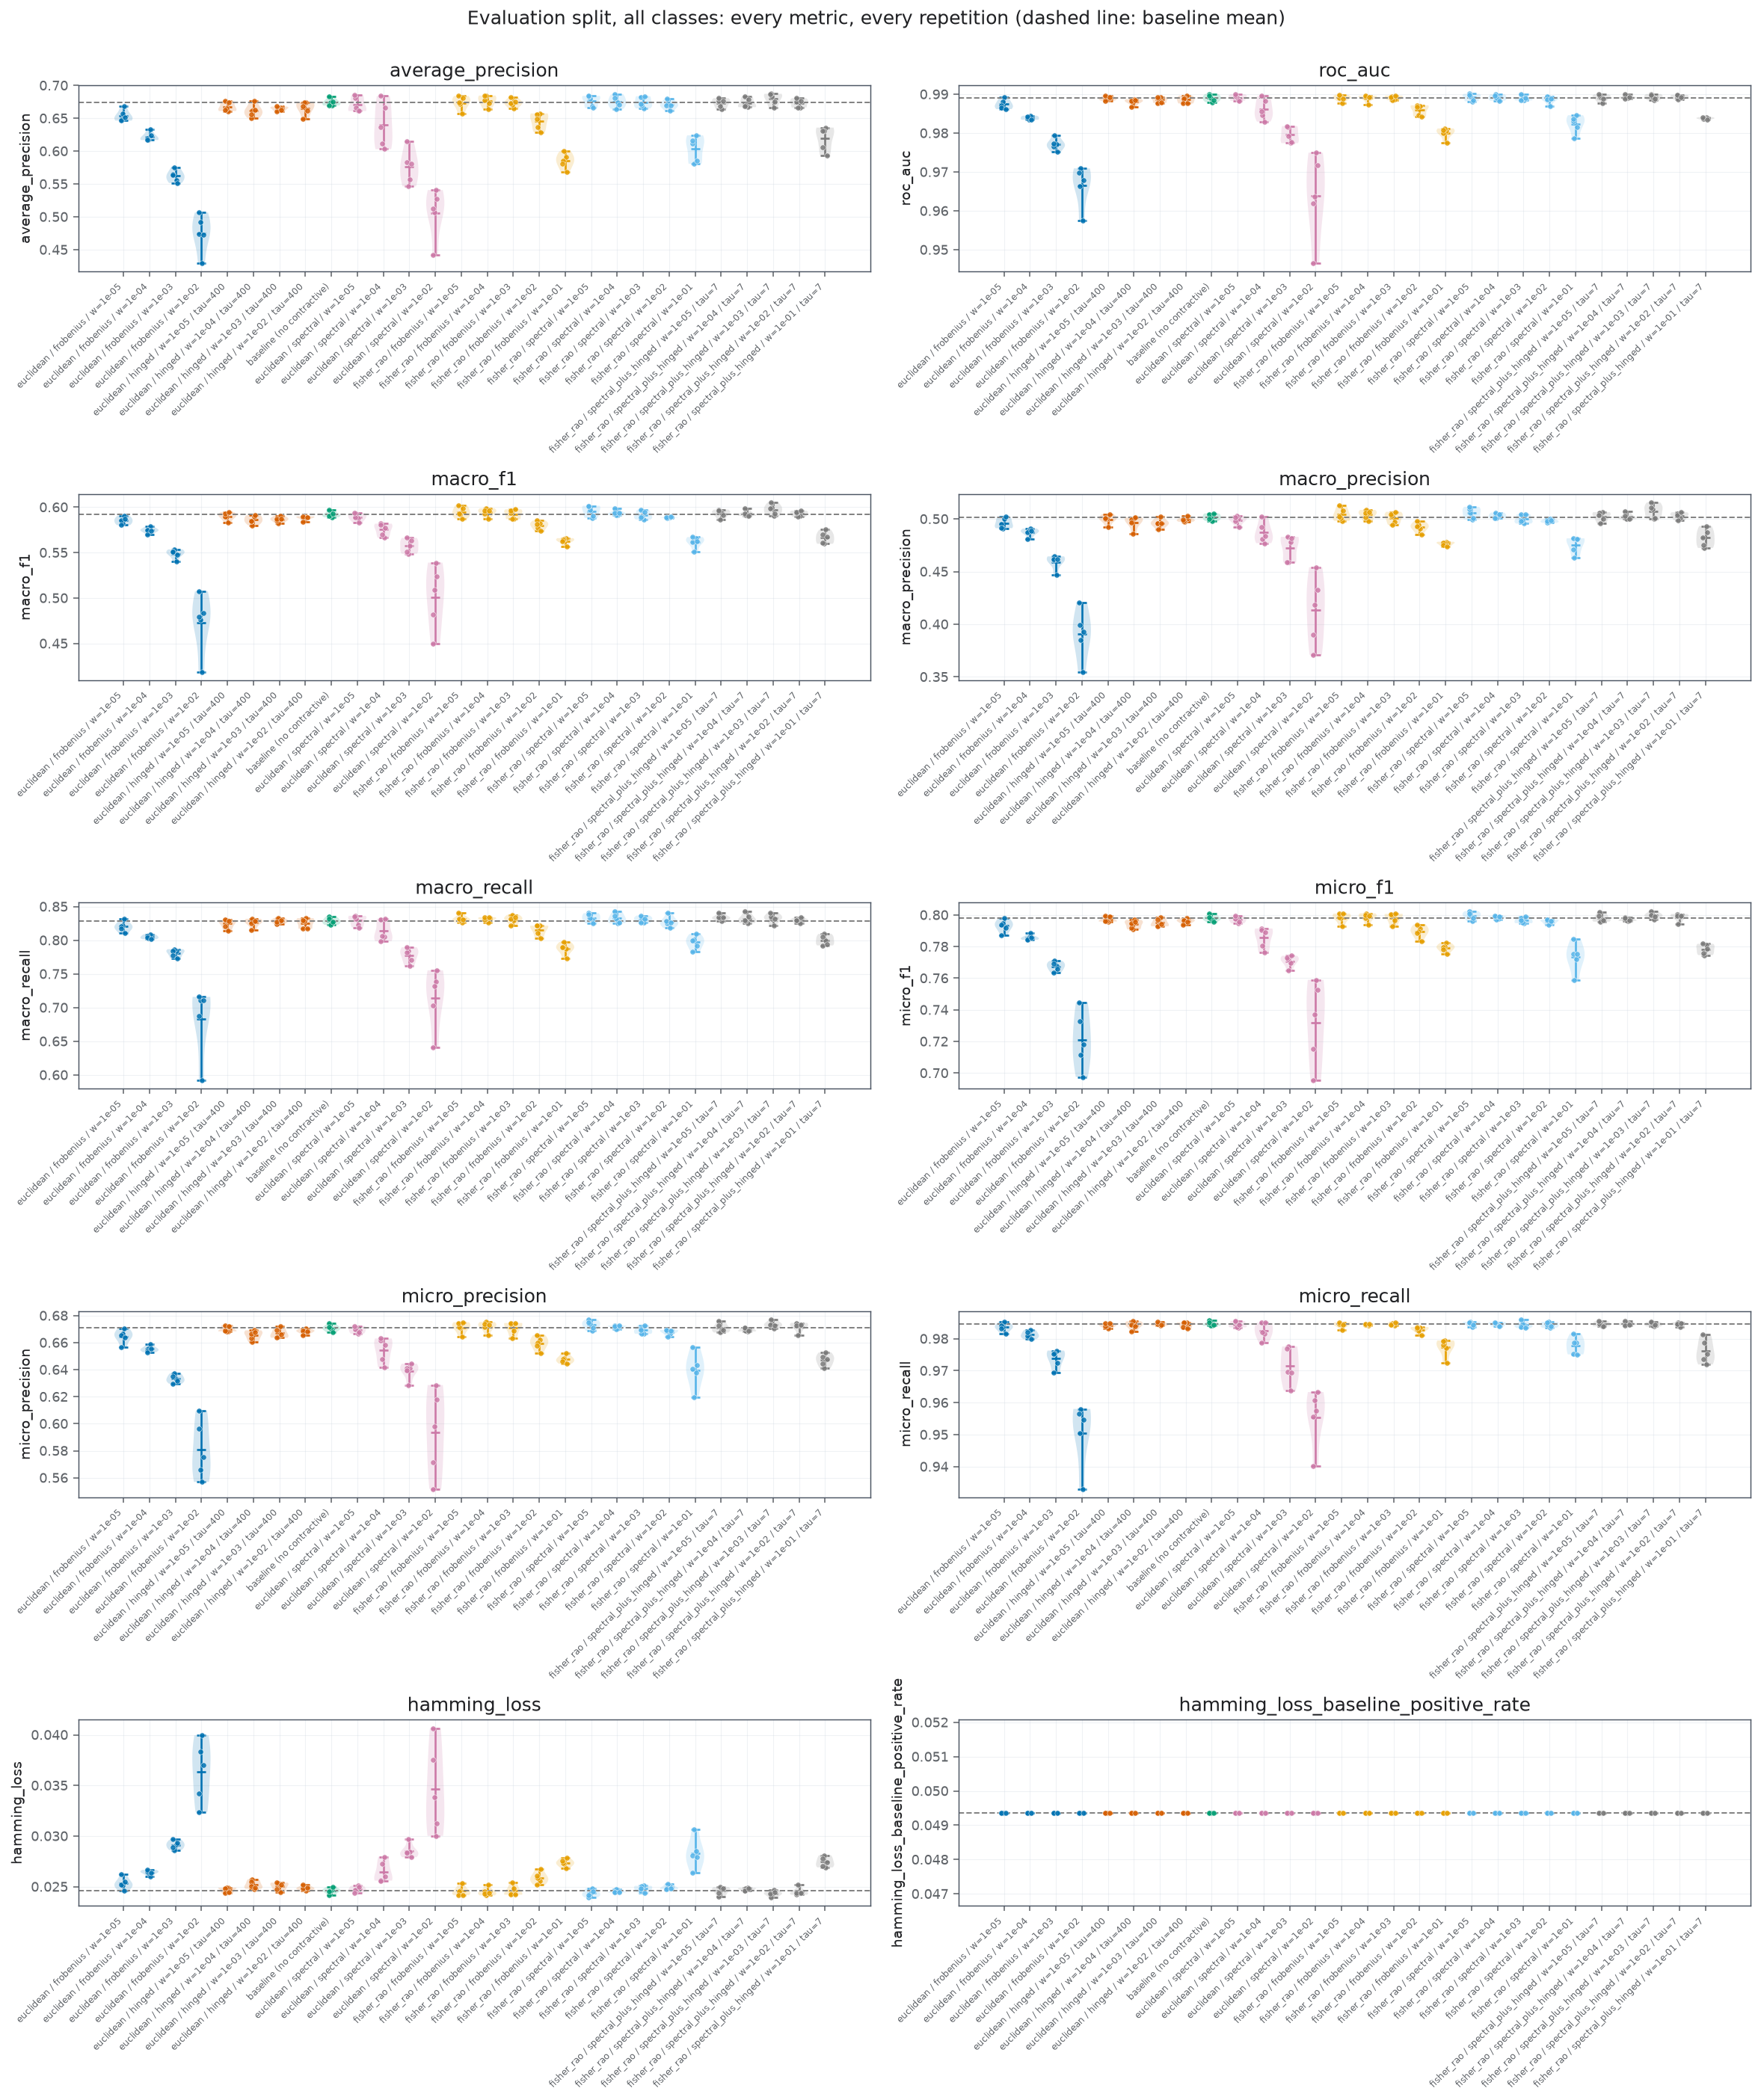

In [7]:
plot_metric_panels(prediction_frame, evaluation.ALL_CLASSES_SCOPE, "test", "Evaluation split, all classes: every metric, every repetition (dashed line: baseline mean)")

## Generalization gap between the training and evaluation split

### Methodology

#### Theoretical

A contractive penalty is a regularizer, so its intended effect is to reduce the gap
$\Delta_c = \mathrm{AP}^{\mathrm{train}}_c - \mathrm{AP}^{\mathrm{test}}_c$ without
reducing $\mathrm{AP}^{\mathrm{test}}_c$. Three outcomes are distinguishable here and only
here: a gap that shrinks with evaluation quality held is regularization working; a gap
that shrinks because both terms fall is capacity destruction; a gap unchanged while both
fall is an optimization failure.

#### Implementation

The gap is computed per repetition, pairing the training and evaluation values of the same
run, and then shown as a distribution across repetitions. Pairing within a run removes the
between-seed variance that would otherwise dominate a five-observation comparison.

#### Figure descriptions

The left panel shows, per grid cell, the distribution over repetitions of the paired
train-minus-test difference in average precision within the fair scope; the y-axis is that
difference, and zero means the model performs identically on both splits. The right panel
shows the two absolute levels for the same cells, with training values as open markers and
evaluation values as filled markers connected per cell, so a fall in the gap can be read
as caused by either term. Both x-axes list cells in the same order as above.

### Remarks

### Notes

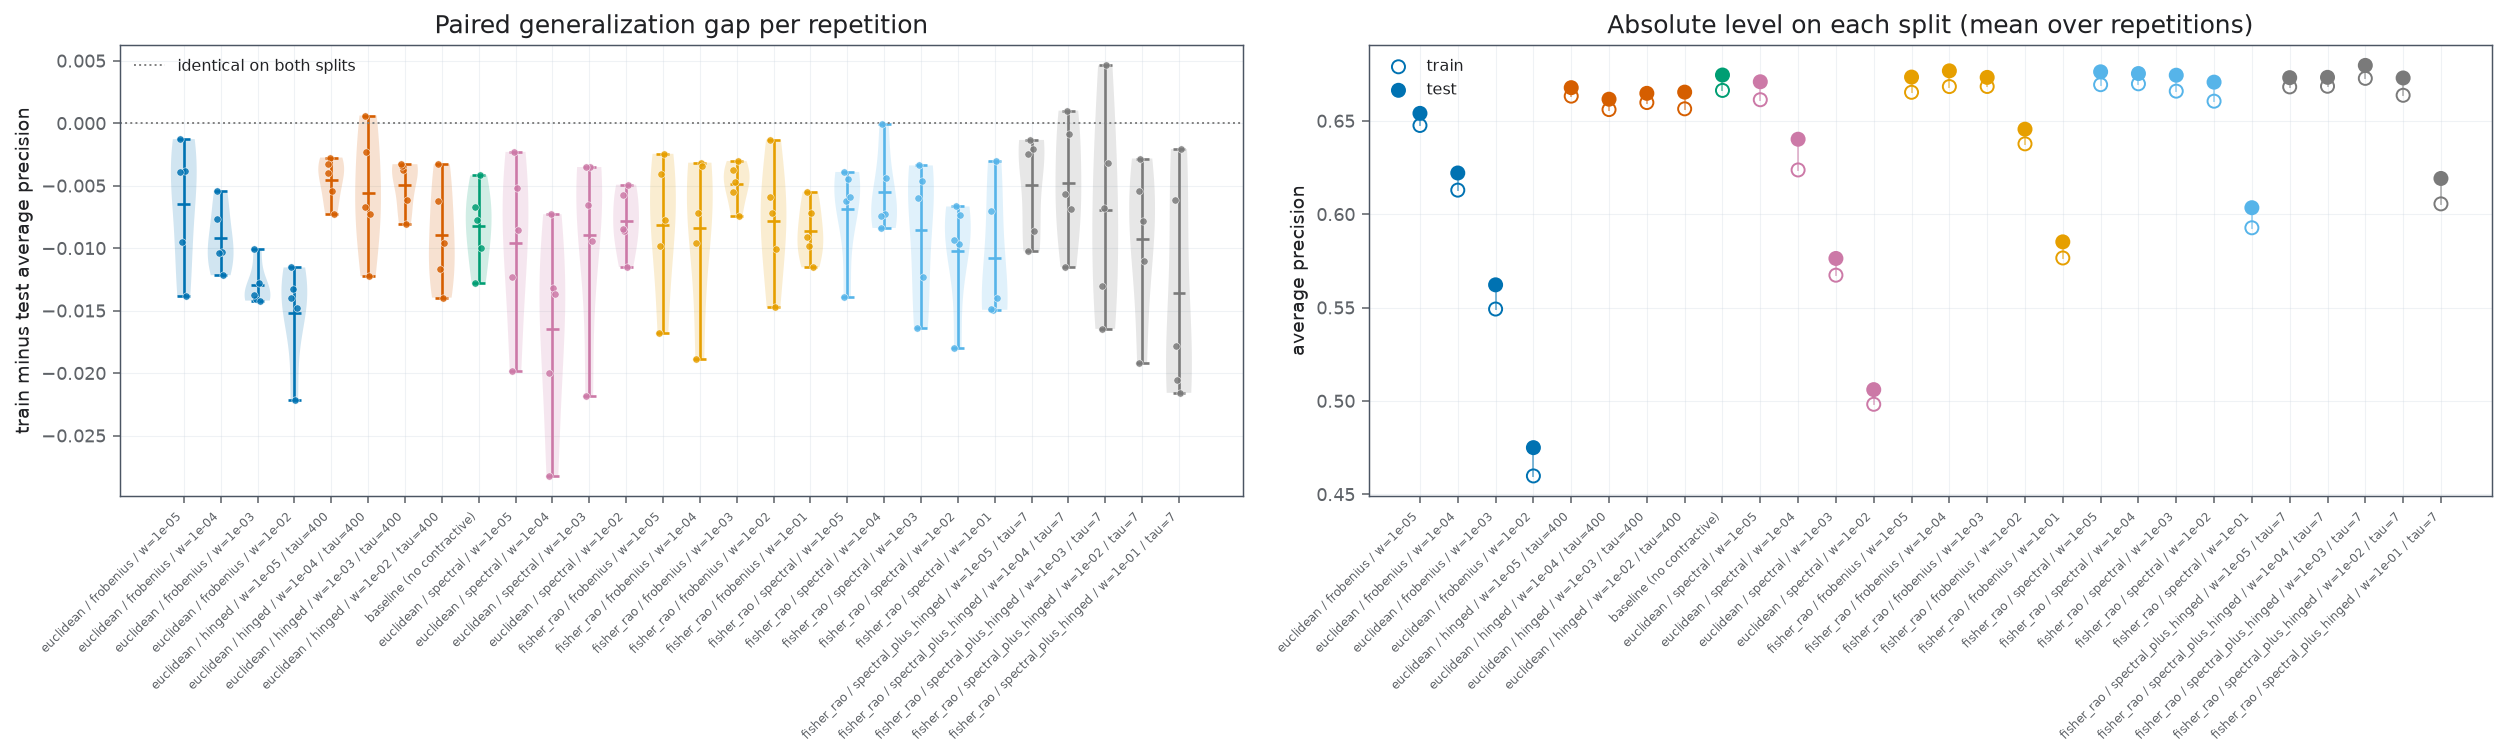

In [8]:
paired = (
    prediction_frame.query("metric == 'average_precision' and scope == @evaluation.FAIR_SCOPE")
    .pivot_table(index=["cell_label", "repetition"], columns="split", values="value")
    .dropna()
)
paired["gap"] = paired["train"] - paired["test"]

figure, (gap_axis, level_axis) = plt.subplots(1, 2, figsize=(18.0, 5.5), dpi=theme.figure_dpi)
for position, cell in enumerate(CELL_ORDER):
    if cell not in paired.index.get_level_values("cell_label"):
        continue
    plot_violin_with_points(
        paired.loc[cell, "gap"].to_numpy(), position=position, ax=gap_axis, width=0.7,
        color=CELL_COLOR[cell], point_size=14.0, jitter=0.10, theme=theme,
    )
gap_axis.axhline(0.0, color="grey", linestyle=":", linewidth=1, label="identical on both splits")
gap_axis.set_xticks(range(len(CELL_ORDER)))
gap_axis.set_xticklabels(CELL_ORDER, rotation=45, ha="right", fontsize=6)
gap_axis.set(ylabel="train minus test average precision", title="Paired generalization gap per repetition")
gap_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
gap_axis.legend(fontsize=8, frameon=theme.legend_frame)

levels = paired.groupby("cell_label")[["train", "test"]].mean().reindex(CELL_ORDER).dropna()
positions = [CELL_ORDER.index(cell) for cell in levels.index]
for position, (cell, row) in zip(positions, levels.iterrows()):
    level_axis.plot([position, position], [row["train"], row["test"]], color=CELL_COLOR[cell], alpha=0.5, linewidth=1)
level_axis.scatter(positions, levels["train"], facecolors="none", edgecolors=[CELL_COLOR[c] for c in levels.index], s=45, label="train")
level_axis.scatter(positions, levels["test"], color=[CELL_COLOR[c] for c in levels.index], s=45, label="test")
level_axis.set_xticks(range(len(CELL_ORDER)))
level_axis.set_xticklabels(CELL_ORDER, rotation=45, ha="right", fontsize=6)
level_axis.set(ylabel="average precision", title="Absolute level on each split (mean over repetitions)")
level_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
level_axis.legend(fontsize=8, frameon=theme.legend_frame)
figure.tight_layout()

## Do the threshold metrics track average precision?

### Methodology

#### Theoretical

This is the test the metric definitions above set up. If a penalty degrades the
representation, ranking and threshold metrics fall together and are strongly positively
associated across the grid. If a penalty merely contracts the score scale, average
precision stays flat while threshold metrics fall, and the association weakens or
disappears.

The association is measured with Spearman's $\rho$ across grid cells, using cell means, so
it asks whether cells that rank better also score better at the fixed threshold. Spearman
rather than Pearson because only the monotone relationship is of interest and the metrics
are on different scales.

The mechanism is then tested directly rather than inferred: for each cell the spread of
predicted probabilities is measured as the mean over available entries of
$\hat y_{ik}$ and its standard deviation. A cell whose probability spread collapses while
its average precision holds is exhibiting a scale effect, not an information loss.

#### Implementation

Correlations use one observation per grid cell, the mean over its five repetitions, in the
fair scope on the evaluation split. Probability spread is recomputed from the stored
logits of repetition 0 of each cell with `probabilities_from_logits`, restricted to
available entries within the fair scope.

#### Figure descriptions

The first table lists Spearman $\rho$ between each metric and `average_precision` across
grid cells, with the number of cells contributing. The scatter grid that follows plots, per
panel, `average_precision` on the x-axis against the named metric on the y-axis; each point
is one grid cell, colored by penalty family, and the panel title carries that pair's
Spearman $\rho$. A tight monotone cloud means the two metrics carry the same ordering of
cells; a flat or scattered cloud means they disagree, which for a threshold metric
indicates a calibration effect. The final figure plots the mean predicted probability over
available entries against average precision, one point per cell, with the same coloring;
the horizontal line marks the empirical positive rate, the value a perfectly calibrated
uninformative model would predict everywhere.

### Remarks

### Notes

In [9]:
cell_means = (
    test_frame.query("scope == @evaluation.FAIR_SCOPE")
    .pivot_table(index="cell_label", columns="metric", values="value", aggfunc="mean")
    .reindex(CELL_ORDER).dropna(how="all")
)
correlation_rows = []
for metric in METRIC_ORDER:
    if metric == "average_precision":
        continue
    paired_values = cell_means[["average_precision", metric]].dropna()
    rho, p_value = spearmanr(paired_values["average_precision"], paired_values[metric])
    correlation_rows.append({
        "metric": metric, "spearman_rho_vs_average_precision": rho,
        "p_value": p_value, "cells": len(paired_values),
    })
correlation_frame = pd.DataFrame(correlation_rows).sort_values("spearman_rho_vs_average_precision")
display(correlation_frame.round(4))

/tmp/ipykernel_195758/2878978247.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p_value = spearmanr(paired_values["average_precision"], paired_values[metric])


,metric,spearman_rho_vs_average_precision,p_value,cells
7,hamming_loss,-0.9546,0.0,28
6,micro_recall,0.8593,0.0,28
0,roc_auc,0.9146,0.0,28
3,macro_recall,0.9414,0.0,28
4,micro_f1,0.9496,0.0,28
5,micro_precision,0.9546,0.0,28
2,macro_precision,0.9677,0.0,28
1,macro_f1,0.9693,0.0,28
8,hamming_loss_baseline_positive_rate,NaN,NaN,28


/tmp/ipykernel_195758/1775014952.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(values["average_precision"], values[metric])


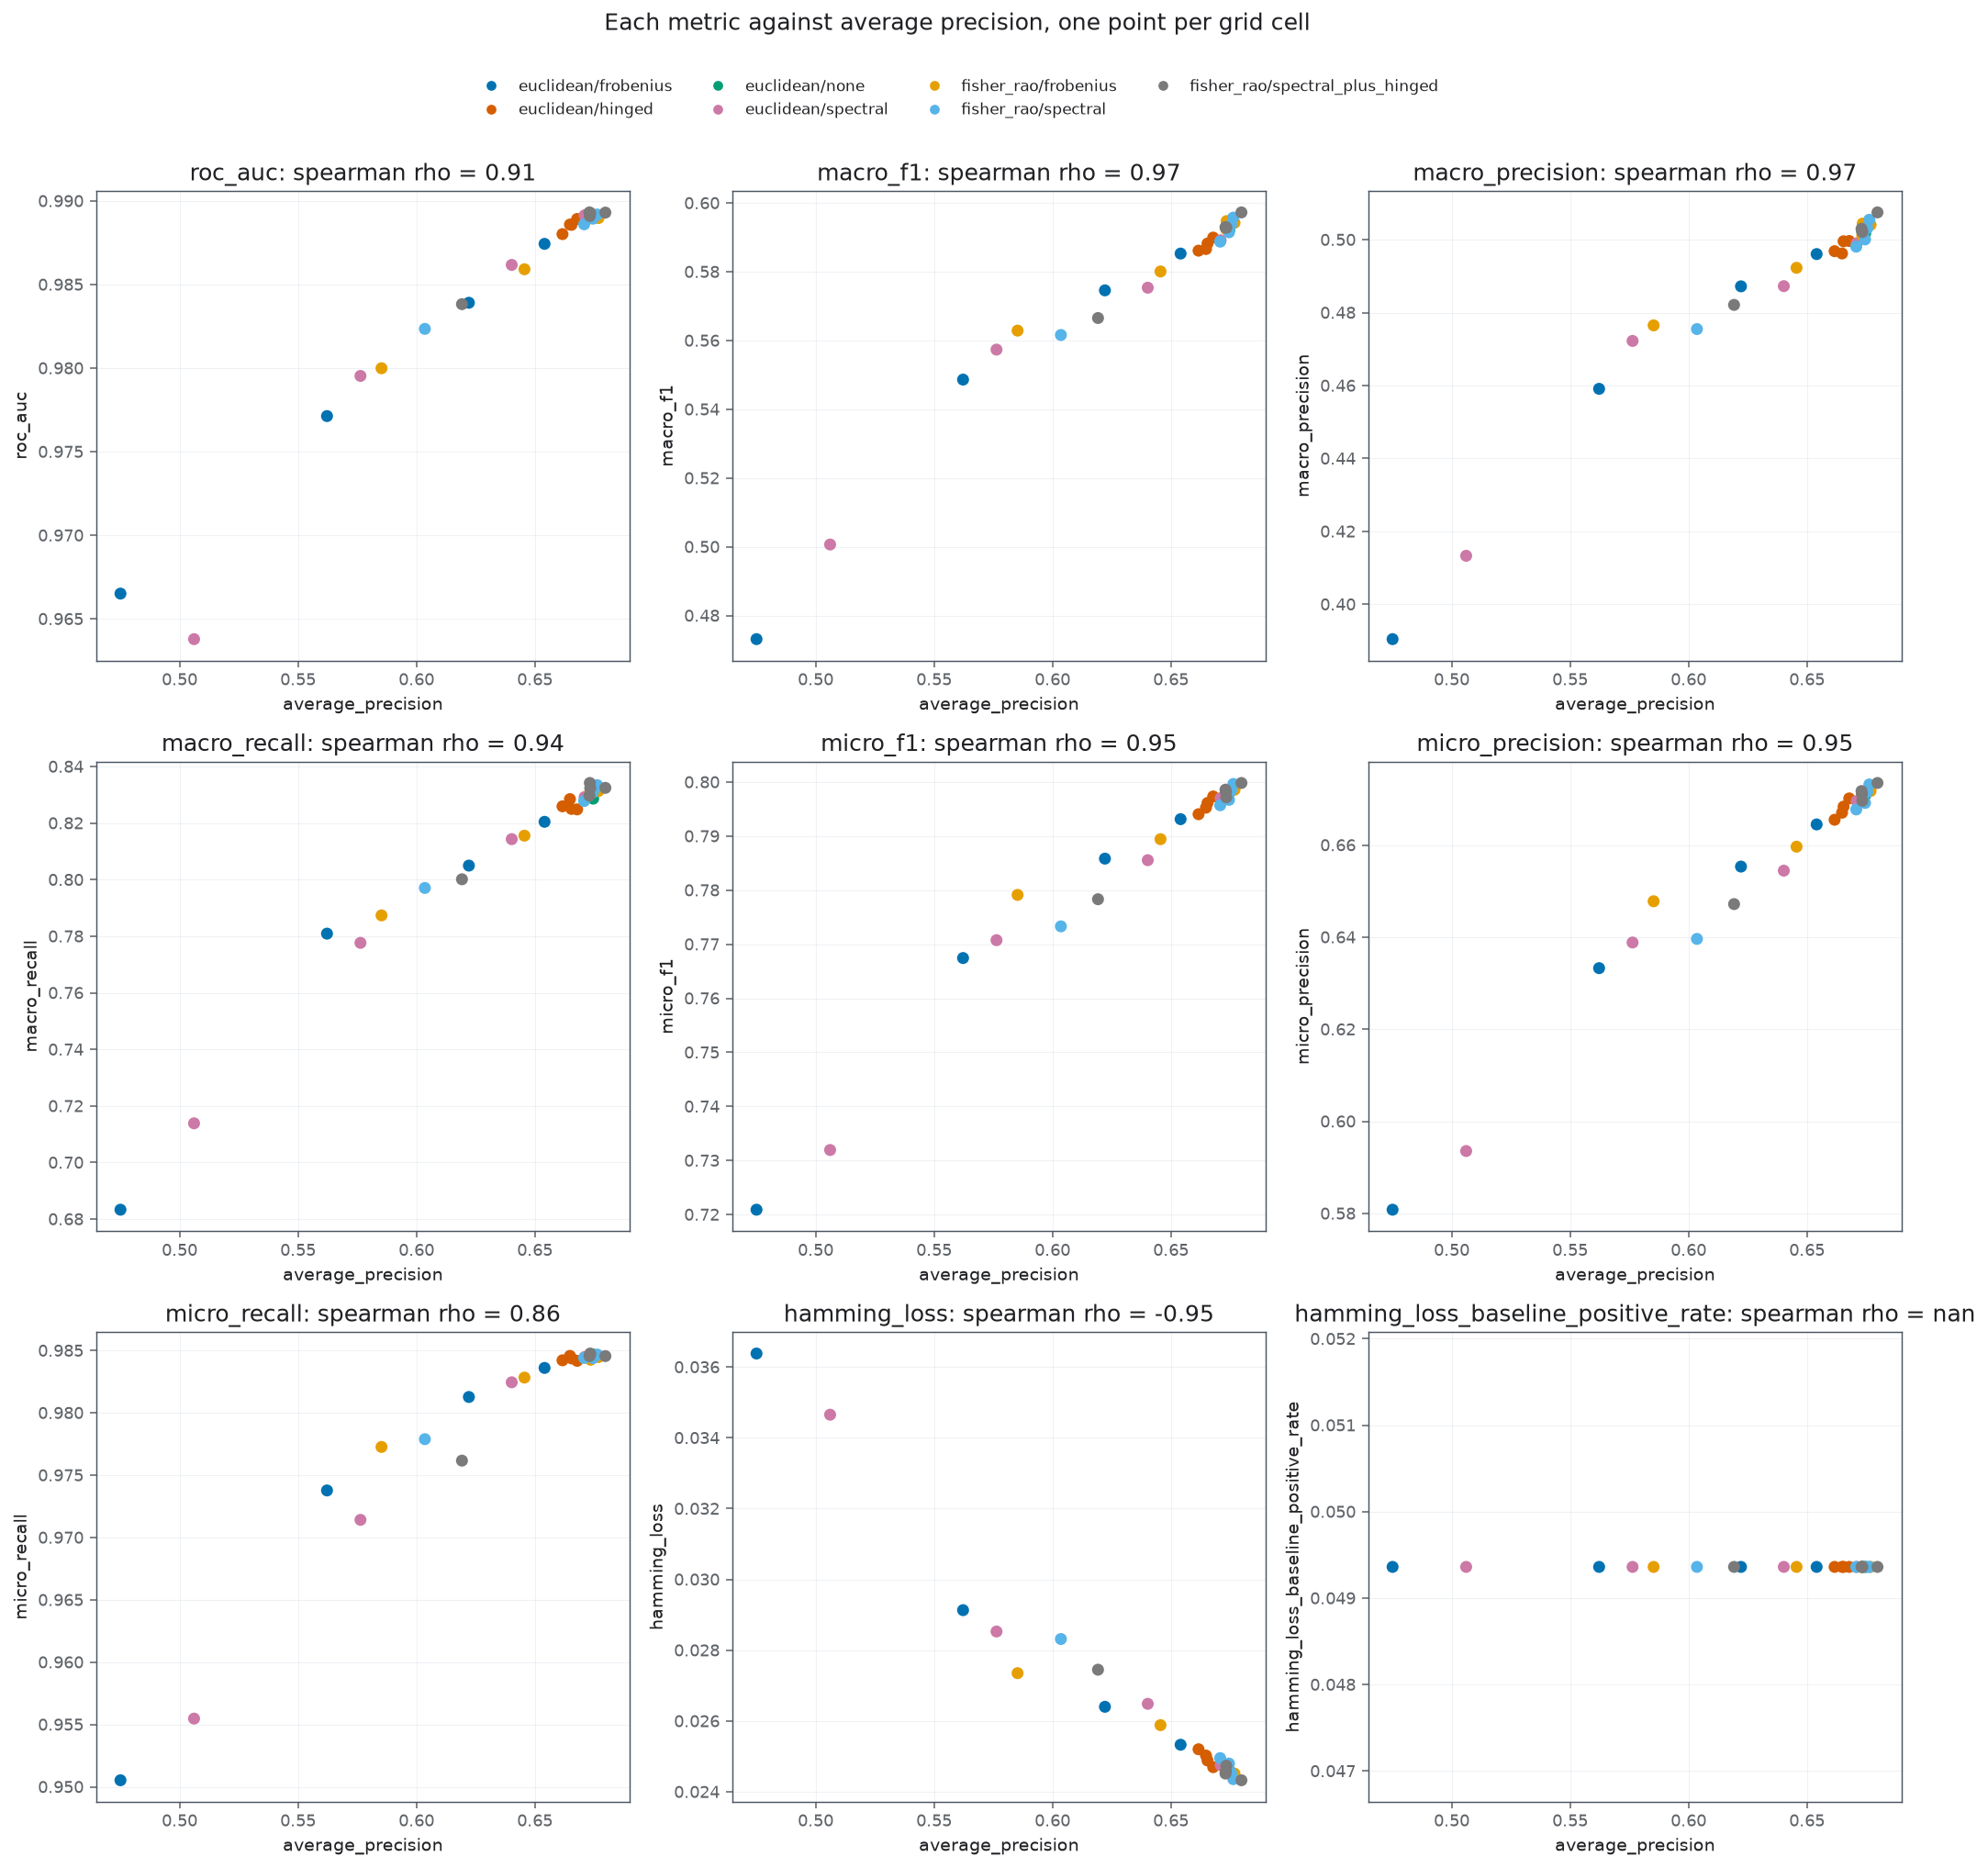

In [10]:
panel_metrics = [m for m in METRIC_ORDER if m != "average_precision"]
rows, columns = 3, 3
figure, axes = plt.subplots(rows, columns, figsize=(15.0, 4.6 * rows), dpi=theme.figure_dpi)
for axis, metric in zip(axes.ravel(), panel_metrics):
    values = cell_means[["average_precision", metric]].dropna()
    colors = [CELL_COLOR[cell] for cell in values.index]
    axis.scatter(values["average_precision"], values[metric], color=colors, s=45, edgecolor="none")
    rho, _ = spearmanr(values["average_precision"], values[metric])
    axis.set(xlabel="average_precision", ylabel=metric, title=f"{metric}: spearman rho = {rho:.2f}")
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
for axis in axes.ravel()[len(panel_metrics):]:
    axis.axis("off")
handles = [plt.Line2D([], [], marker="o", linestyle="", color=FAMILY_COLOR[f], label="/".join(f)) for f in FAMILIES]
figure.legend(handles=handles, loc="upper center", ncol=min(len(FAMILIES), 4), frameon=theme.legend_frame, bbox_to_anchor=(0.5, 1.02))
figure.suptitle("Each metric against average precision, one point per grid cell", y=1.05, fontsize=13)
figure.tight_layout()

,mean_probability,std_probability,mean_logit_std
cell_label,,,
fisher_rao / spectral / w=1e-05,0.0720,0.2379,5.5562
fisher_rao / spectral / w=1e-04,0.0717,0.2382,5.9261
fisher_rao / spectral / w=1e-03,0.0719,0.2379,5.3787
fisher_rao / spectral / w=1e-02,0.0722,0.2383,5.0665
fisher_rao / spectral / w=1e-01,0.0765,0.2410,4.7260
fisher_rao / spectral_plus_hinged / w=1e-05 / tau=7,0.0716,0.2377,5.3874
fisher_rao / spectral_plus_hinged / w=1e-04 / tau=7,0.0717,0.2381,5.8832
fisher_rao / spectral_plus_hinged / w=1e-03 / tau=7,0.0715,0.2380,5.7603
fisher_rao / spectral_plus_hinged / w=1e-02 / tau=7,0.0711,0.2370,5.5669


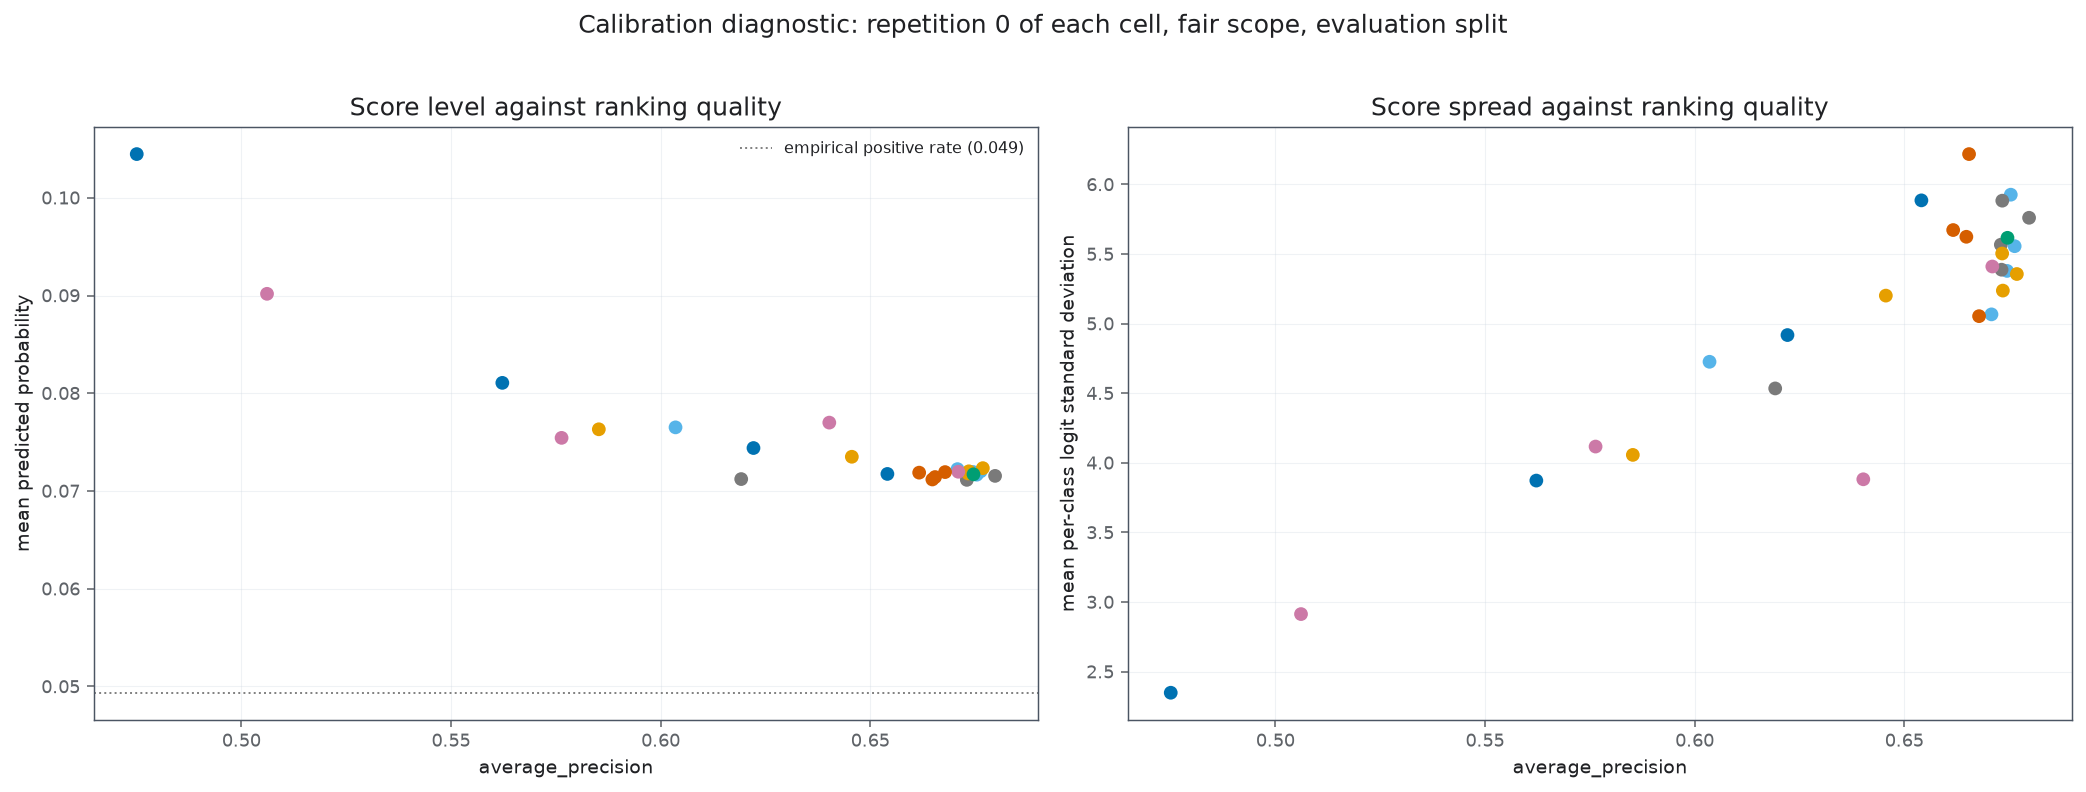

In [11]:
figure, (probability_axis, logit_axis) = plt.subplots(1, 2, figsize=(15.0, 5.5), dpi=theme.figure_dpi)
joined = spread_frame.join(cell_means["average_precision"]).dropna()
colors = [CELL_COLOR[cell] for cell in joined.index]
probability_axis.scatter(joined["average_precision"], joined["mean_probability"], color=colors, s=50, edgecolor="none")
probability_axis.axhline(positive_rate, color="grey", linestyle=":", linewidth=1, label=f"empirical positive rate ({positive_rate:.3f})")
probability_axis.set(xlabel="average_precision", ylabel="mean predicted probability", title="Score level against ranking quality")
probability_axis.legend(fontsize=8, frameon=theme.legend_frame)
probability_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)

logit_axis.scatter(joined["average_precision"], joined["mean_logit_std"], color=colors, s=50, edgecolor="none")
logit_axis.set(xlabel="average_precision", ylabel="mean per-class logit standard deviation", title="Score spread against ranking quality")
logit_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("Calibration diagnostic: repetition 0 of each cell, fair scope, evaluation split", y=1.02, fontsize=13)
figure.tight_layout()
display(spread_frame.round(4))

## Per-class average precision

### Methodology

#### Theoretical

A macro average over several hundred mostly rare classes is a single number over a very
heterogeneous population. Two cells with the same macro average precision can differ
completely in which classes they predict well. The per-class distribution shows whether a
penalty acts uniformly or trades frequent classes against rare ones.

#### Implementation

Per-class records are computed with `per_class_metrics` on the evaluation split within the
fair scope, for repetition 0 of every cell, and carry each class's available positive
count so classes can be stratified by prevalence. Class indices refer to positions in the
original class axis, not in the masked subset, so records stay joinable across scopes.

#### Figure descriptions

The left panel shows, per cell, the distribution of per-class average precision over the
fair-scope classes; each violin uses every class and the overlaid points are a
deterministic subsample of 150 classes drawn with a fixed seed, since drawing several
hundred points per violin is unreadable. The right panel plots each class's available
positive count on a logarithmic x-axis against its average precision on the y-axis, for
the baseline and for the best and worst cell by macro average precision, so the
prevalence dependence of any difference is visible.

### Remarks

### Notes

In [12]:
PER_CLASS_POINT_SAMPLE = 150

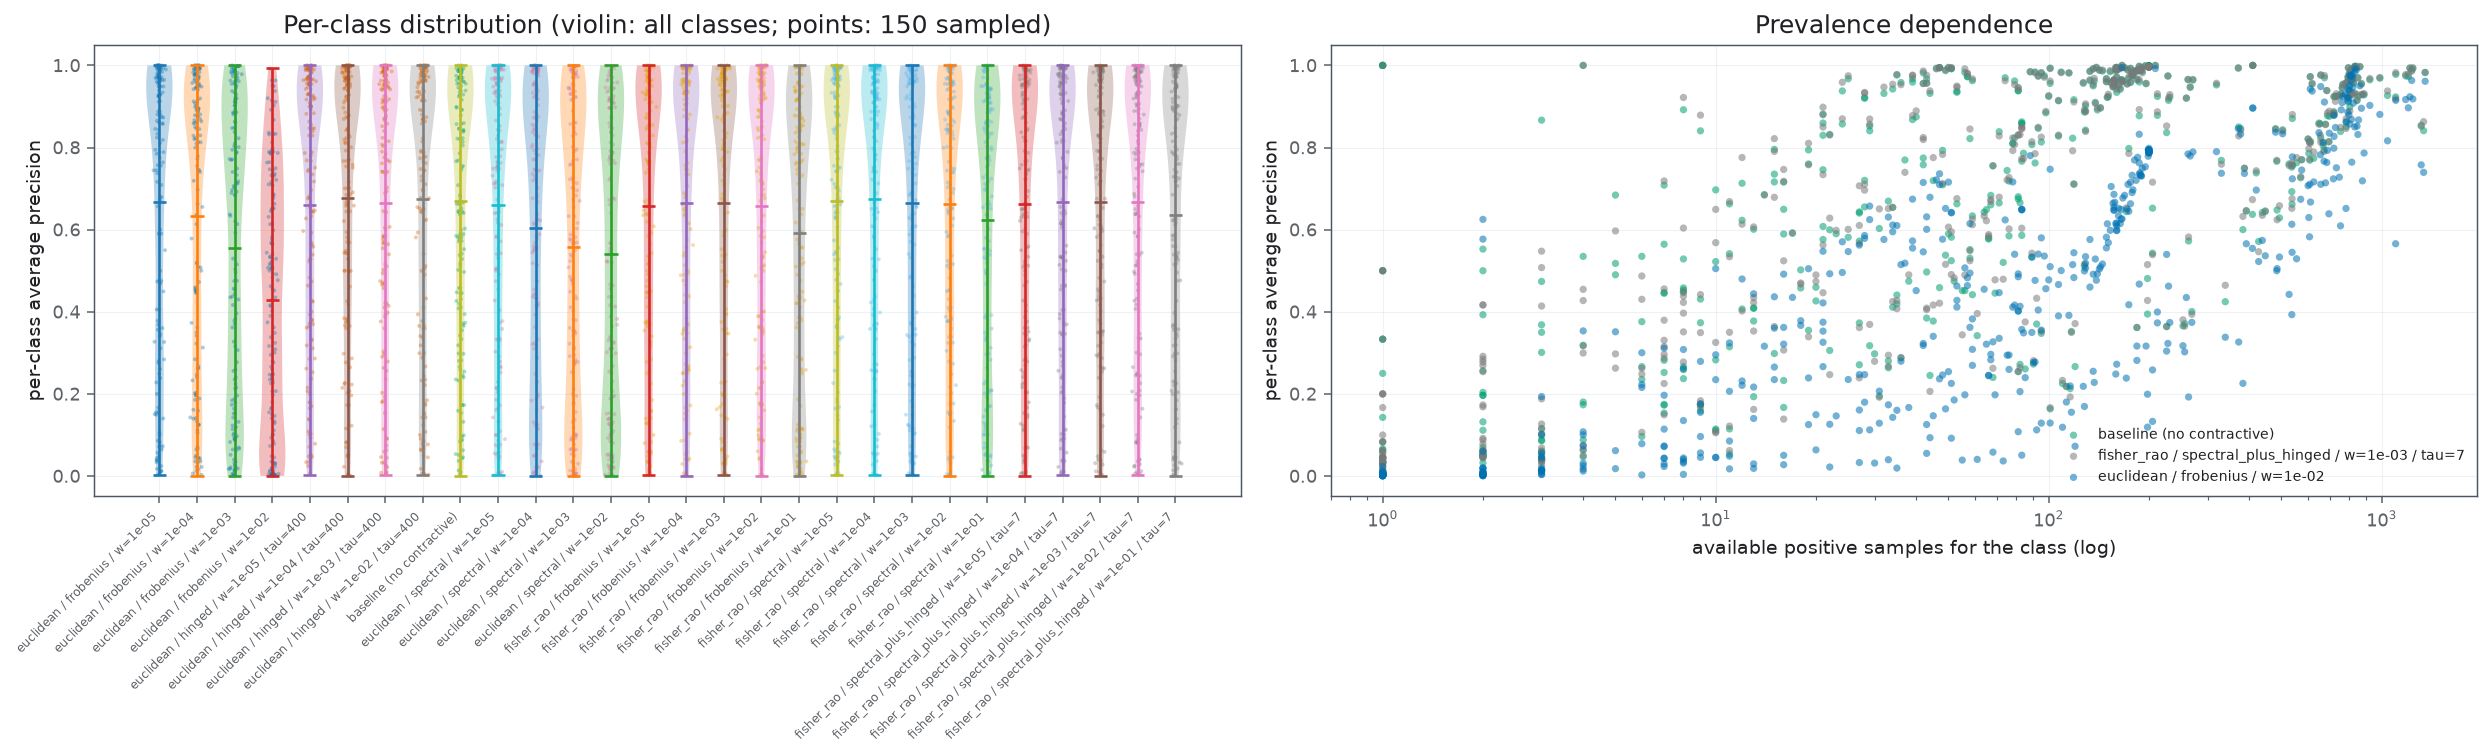

In [13]:
#TODO - tutaj lepsze klasy dobrać 

point_rng = np.random.default_rng(SAMPLE_SEED)
figure, (distribution_axis, prevalence_axis) = plt.subplots(1, 2, figsize=(18.0, 5.5), dpi=theme.figure_dpi)
for position, cell in enumerate(CELL_ORDER):
    values = per_class_frame.query("cell_label == @cell")["average_precision"].dropna().to_numpy()
    if not len(values):
        continue
    shown = values if len(values) <= PER_CLASS_POINT_SAMPLE else point_rng.choice(values, PER_CLASS_POINT_SAMPLE, replace=False)
    distribution_axis.violinplot([values], positions=[position], widths=0.7, showmeans=True)
    distribution_axis.scatter(
        position + point_rng.normal(0.0, 0.06, size=len(shown)), shown,
        color=CELL_COLOR[cell], s=4, alpha=0.35, edgecolor="none",
    )
distribution_axis.set_xticks(range(len(CELL_ORDER)))
distribution_axis.set_xticklabels(CELL_ORDER, rotation=45, ha="right", fontsize=6)
distribution_axis.set(ylabel="per-class average precision", title=f"Per-class distribution (violin: all classes; points: {PER_CLASS_POINT_SAMPLE} sampled)")
distribution_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)

macro_ranking = cell_means["average_precision"].dropna().sort_values()
highlight = ["baseline (no contractive)", macro_ranking.index[-1], macro_ranking.index[0]]
for cell in dict.fromkeys(highlight):
    subset = per_class_frame.query("cell_label == @cell")
    prevalence_axis.scatter(
        subset["positive_samples"], subset["average_precision"],
        color=CELL_COLOR.get(cell, "grey"), s=14, alpha=0.55, edgecolor="none", label=cell,
    )
prevalence_axis.set_xscale("log")
prevalence_axis.set(xlabel="available positive samples for the class (log)", ylabel="per-class average precision", title="Prevalence dependence")
prevalence_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
prevalence_axis.legend(fontsize=7, frameon=theme.legend_frame)
figure.tight_layout()

## Contrast against the baseline

### Methodology

#### Theoretical

Repetition $r$ of any two cells shares its split and dataloader seeds and differs only in
the run seeds derived from $r$, so observations are matched and the comparison should be
paired. Pairing removes the between-repetition variance, which with five observations is
otherwise large enough to hide a real shift. The reported interval is a two-sided 95%
Student-t interval on the paired differences; a bootstrap over five values would resample
at most five distinct differences and understate the tails.

A cell is called separated from the baseline when the interval excludes zero. With
fifteen swept cells compared against one baseline this is a multiple-comparison setting
and no correction is applied, so a single separated cell near the boundary is weak
evidence; the pattern across a penalty family is what should be read.

#### Implementation

`paired_contrast` pairs on repetition index and drops non-finite observations. The
contrast is computed for average precision in the fair scope on the evaluation split.

#### Figure descriptions

The table lists every swept cell with the number of matched repetitions, the mean paired
difference in average precision against the baseline, its confidence interval, and whether
that interval excludes zero. Positive values favor the swept cell. The figure plots the
mean paired difference per cell with its interval as an error bar; the horizontal line at
zero is the baseline, cells whose interval crosses it are not distinguishable from it, and
color encodes penalty family.

### Remarks

### Notes

In [14]:
def repetition_values(cell_label, metric="average_precision", scope=None, split="test"):
    scope = scope or evaluation.FAIR_SCOPE
    selected = prediction_frame.query(
        "cell_label == @cell_label and metric == @metric and scope == @scope and split == @split"
    )
    return {int(row.repetition): float(row.value) for row in selected.itertuples() if row.repetition is not None}


baseline_values = repetition_values("baseline (no contractive)")
contrast_rows = []
for cell in CELL_ORDER:
    if cell == "baseline (no contractive)":
        continue
    contrast = sweep.paired_contrast(repetition_values(cell), baseline_values)
    contrast_rows.append({"cell_label": cell, **contrast})
contrast_frame = pd.DataFrame(contrast_rows)
display(contrast_frame.round(4))

,cell_label,pairs,mean_difference,ci_low,ci_high,separated_from_zero
0,euclidean / frobenius / w=1e-05,5,-0.0205,-0.0363,-0.0048,True
1,euclidean / frobenius / w=1e-04,5,-0.0525,-0.0654,-0.0395,True
2,euclidean / frobenius / w=1e-03,5,-0.1124,-0.1248,-0.0999,True
3,euclidean / frobenius / w=1e-02,5,-0.1996,-0.2357,-0.1635,True
4,euclidean / hinged / w=1e-05 / tau=400,5,-0.0068,-0.0196,0.0060,False
5,euclidean / hinged / w=1e-04 / tau=400,5,-0.0130,-0.0305,0.0046,False
6,euclidean / hinged / w=1e-03 / tau=400,5,-0.0098,-0.0204,0.0008,False
7,euclidean / hinged / w=1e-02 / tau=400,5,-0.0092,-0.0225,0.0041,False
8,euclidean / spectral / w=1e-05,5,-0.0036,-0.0181,0.0108,False
9,euclidean / spectral / w=1e-04,5,-0.0344,-0.0718,0.0030,False


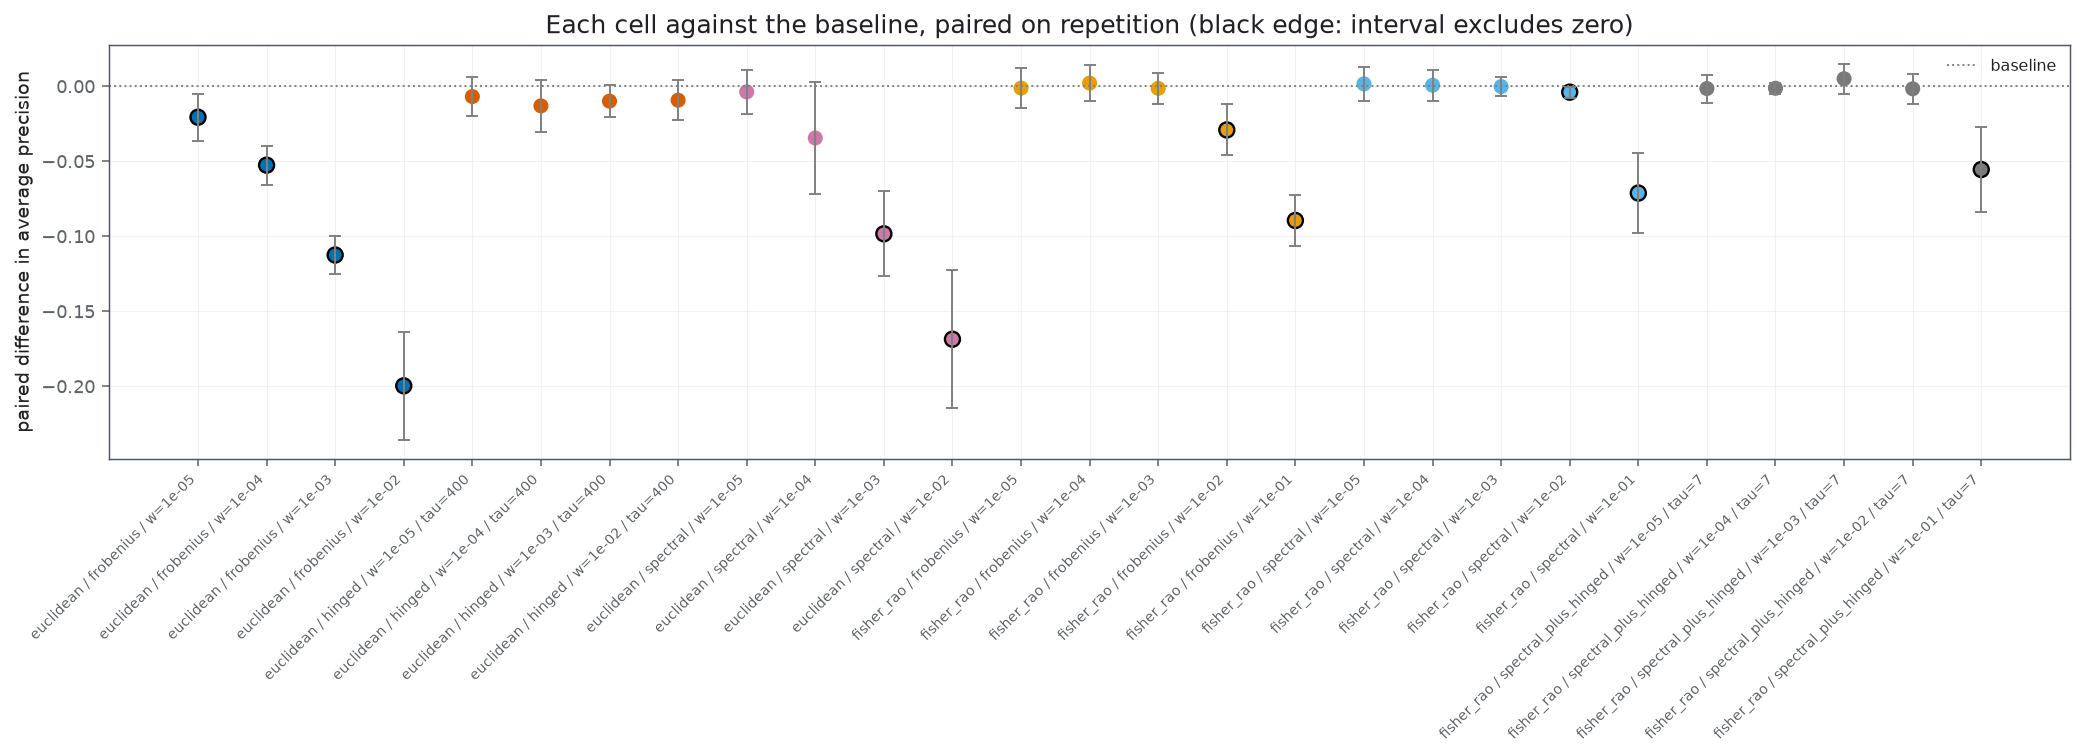

In [15]:
plotted = contrast_frame.dropna(subset=["mean_difference"])
positions = np.arange(len(plotted))
figure, ax = plt.subplots(figsize=(15.0, 5.5), dpi=theme.figure_dpi)
ax.errorbar(
    positions, plotted["mean_difference"],
    yerr=[plotted["mean_difference"] - plotted["ci_low"], plotted["ci_high"] - plotted["mean_difference"]],
    fmt="none", ecolor="grey", elinewidth=1, capsize=3,
)
ax.scatter(
    positions, plotted["mean_difference"], s=60,
    color=[CELL_COLOR[cell] for cell in plotted["cell_label"]],
    edgecolor=["black" if separated else "none" for separated in plotted["separated_from_zero"]], linewidth=1.2,
)
ax.axhline(0.0, color="grey", linestyle=":", linewidth=1, label="baseline")
ax.set_xticks(positions)
ax.set_xticklabels(plotted["cell_label"], rotation=45, ha="right", fontsize=7)
ax.set(ylabel="paired difference in average precision", title="Each cell against the baseline, paired on repetition (black edge: interval excludes zero)")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(fontsize=8, frameon=theme.legend_frame)
figure.tight_layout()

## Reproducible artifacts

### Methodology

#### Implementation

The measured tables and their provenance are written by the precompute runner, not here;
this notebook adds only the two summaries it derives from them, the paired baseline
contrasts and the metric correlations, both of which are a few operations on tables
already in memory. Provenance for the measured part, including the commit, the device and
the source hashes of the analysis modules, lives in the runner's `metadata.json`.

The results directory is deliberately not versioned: it is regenerable from the runner
and its recorded provenance, and the tables are large.

### Remarks

### Notes

In [16]:
# The precompute already wrote the measured tables and the provenance record. Only the
# summaries derived here are added, so nothing is stored twice under two names.
derived = {
    "baseline_contrasts": contrast_frame,
    "metric_correlations": correlation_frame,
}
for name, frame in derived.items():
    frame.to_csv(ARTIFACT_DIR / f"{name}.csv", index=False)

print("derived tables written:", sorted(derived))
print("precomputed tables present:", sorted(path.name for path in ARTIFACT_DIR.glob("*.csv")))

derived tables written: ['baseline_contrasts', 'metric_correlations']
precomputed tables present: ['baseline_contrasts.csv', 'calibration_diagnostic.csv', 'fair_scope_classes.csv', 'grid.csv', 'metric_correlations.csv', 'per_class_metrics.csv', 'prediction_metrics.csv', 'sample_indices.csv']


## Results / Summary

### LLM

**No configuration improves prediction over the baseline.** Evaluated on the complete
splits (33,650 training and 4,205 evaluation pixels, 508 of 508 classes active in both),
the baseline reaches 0.6746 average precision in the fair scope. The best swept cell,
Fisher-Rao spectral-plus-hinge at $\lambda=10^{-3}$, reaches 0.6798, a paired difference of
+0.0052 whose 95% interval $[-0.0049, +0.0152]$ contains zero. No cell's interval excludes
zero on the positive side.

**The input geometry decides whether the penalty is harmless or destructive.** Across four
decades of weight the Fisher-Rao arm stays statistically indistinguishable from the
baseline, while the Euclidean arm degrades steeply: Frobenius falls to 0.4750 at
$\lambda=10^{-2}$ (a paired difference of -0.1996) and spectral to 0.5061 (-0.1685). At
matched nominal weight this is the difference between a penalty that costs nothing and one
that removes a fifth of the model's ranking quality. Nominal weights are not comparable
across geometries, so this is a statement about the configured grid, not about equal
regularization strength.

**A hypothesis stated in this notebook's methodology is not supported by its own data.**
The metric definitions section argued that a contractive penalty could contract the logit
scale and depress threshold-dependent metrics while leaving ranking metrics intact, which
would make a threshold metric misleading on its own. The measurement contradicts this:
across grid cells every threshold metric correlates strongly with average precision
(macro F1 0.97, macro precision 0.97, micro precision 0.96, micro F1 0.95, macro recall
0.94, micro recall 0.86, and Hamming loss -0.96 as expected from its inverted sign). The
observed degradation is therefore a genuine loss of information in the representation, not
a calibration artifact. The distinction still needs to be checked rather than assumed, but
in this campaign it does not explain anything.

**The Euclidean hinge protects by being nearly inert.** It stays within 0.009 of the
baseline at every weight, changing neither prediction nor, as `part_2` shows, the
representation. It avoids the collapse of the other Euclidean penalties by barely
engaging, which is not the same as solving the problem.

**Caveats.** Fifteen swept cells are compared against one baseline with no
multiple-comparison correction, so a single near-boundary cell is weak evidence; the
consistency across a penalty family is what carries weight here. Five repetitions bound
seed noise for this dataset and split only. The evaluation applies the recorded
availability mask, which is stricter than the head's own training convention of treating
unavailable labels as negative.

### Person